<a href="https://colab.research.google.com/github/adiiityn/smartshield-malayalam-cyberbullying-detection/blob/main/finalproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow pandas numpy scikit-learn matplotlib openpyxl
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
import pandas as pd

good_df = pd.read_csv("goodwords_dataset.csv")
bad_df = pd.read_csv("badword_dataset.csv")

good_df["label"] = 1
bad_df["label"] = 0

df = pd.concat([good_df, bad_df], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)

texts = df["text"].astype(str)
labels = df["label"].values


In [4]:
import pandas as pd

# ✅ Correct way to read CSV (UTF-8 safe)
good_df = pd.read_csv("goodwords_dataset.csv", encoding="utf-8")
bad_df = pd.read_csv("badword_dataset.csv", encoding="utf-8")

# Ensure text column is string (no encoding tricks)
good_df["text"] = good_df["text"].astype(str)
bad_df["text"] = bad_df["text"].astype(str)

# Labels
good_df["label"] = 1
bad_df["label"] = 0

# Combine
df = pd.concat([good_df, bad_df], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)

texts = df["text"]
labels = df["label"].values

In [5]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.strip()

texts = texts.apply(clean_text)


In [6]:
import random

sentences = []
labels = []

good_df = good_df.rename(columns={good_df.columns[0]: 'text'})
good_words = good_df["text"].astype(str).tolist()
bad_words  = bad_df["text"].astype(str).tolist()

# Bad sentences
for _ in range(3000):
    w = str(random.choice(bad_words))
    sentences.append(f"you are {w}")
    labels.append(0)

# Good sentences
for _ in range(3000):
    w = str(random.choice(good_words))
    sentences.append(f"you are very {w}")
    labels.append(1)

# Add original words too
sentences += good_words + bad_words
labels += [1]*len(good_words) + [0]*len(bad_words)

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 🔥 CRITICAL FIX: disable default filters
tokenizer = Tokenizer(
    oov_token="<OOV>",
    filters=''   # <-- THIS preserves Malayalam characters
)

tokenizer.fit_on_texts(sentences)

X = tokenizer.texts_to_sequences(sentences)
X = pad_sequences(X, maxlen=20)

y = np.array(labels)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(sentences)

X = tokenizer.texts_to_sequences(sentences)
X = pad_sequences(X, maxlen=20)

y = np.array(labels)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=20),

    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(32)),
    Dropout(0.3),

    Dense(24, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [11]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 1.0000 - loss: 3.7171e-04 - val_accuracy: 0.9974 - val_loss: 0.0067
Epoch 2/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 1.0000 - loss: 1.5573e-04 - val_accuracy: 0.9974 - val_loss: 0.0080
Epoch 3/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 1.0000 - loss: 9.2372e-05 - val_accuracy: 0.9974 - val_loss: 0.0091
Epoch 4/15
142/142 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 1.0000 - loss: 6.2985e-05 - val_accuracy: 0.9974 - val_loss: 0.0100


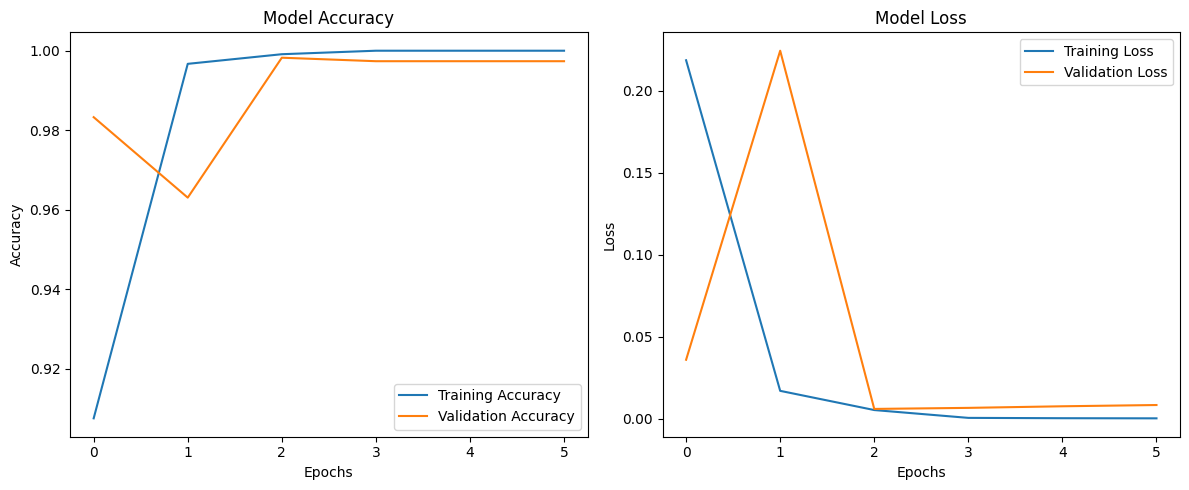

In [13]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# Predict probabilities → convert to 0/1
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Flatten predictions (VERY IMPORTANT)
y_pred = y_pred.flatten()

cm = confusion_matrix(y_test, y_pred)

print(cm)

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
[[660  13]
 [  1 747]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       673
           1       0.98      1.00      0.99       748

    accuracy                           0.99      1421
   macro avg       0.99      0.99      0.99      1421
weighted avg       0.99      0.99      0.99      1421



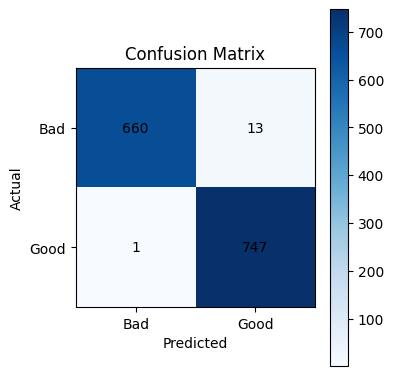

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

# Axis labels
classes = ["Bad", "Good"]
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black")

plt.tight_layout()
plt.show()

In [25]:
import pickle

# Save in new format (recommended)
model.save("cyberbullying_model.keras")

# Save in old format (for Flask compatibility)
model.save("cyberbullying_model.h5")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

In [15]:
!mkdir templates
!mkdir static/css
!mkdir static/js

mkdir: cannot create directory ‘static/css’: No such file or directory
mkdir: cannot create directory ‘static/js’: No such file or directory


In [16]:
!mkdir -p templates
!mkdir -p static/css
!mkdir -p static/js

In [17]:
%%writefile templates/index.html
<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<title>Smart Shield | Cyberbullying Detection System</title>

<link rel="stylesheet" href="{{ url_for('static', filename='css/style.css') }}">

<!-- Malayalam Font -->
<link href="https://fonts.googleapis.com/css2?family=Noto+Sans+Malayalam&display=swap" rel="stylesheet">

</head>


<body>

<!-- Floating animation -->
<div class="float c1"></div>
<div class="float c2"></div>
<div class="float c3"></div>


<header>
<h1>🛡️ Smart Shield</h1>
<p>AI-Based Cyberbullying Detection System</p>
</header>


<section class="hero">
<h2>Protect Online Conversations Using AI</h2>
<button onclick="openChat()">Detect Cyberbullying</button>
</section>


<section class="features">

<div class="card" onclick="showPanel('ai')">
🤖 AI Analysis
</div>

<div class="card" onclick="showPanel('voice')">
🎤 Voice Detection
</div>

<div class="card" onclick="showPanel('realtime')">
⚡ Real-Time Analysis
</div>

<div class="card" onclick="showPanel('accuracy')">
📊 Model Accuracy
</div>

<div class="card" onclick="showPanel('admin')">
🔐 Admin Dashboard
</div>

<div class="card" onclick="showPanel('future')">
🚀 Future Scope
</div>

</section>



<!-- INFORMATION PANEL -->

<div id="panel" class="panel">

<span class="close" onclick="closePanel()">✖</span>

<div id="panelContent"></div>

</div>



<!-- WARNING BOX -->

<div id="warning" class="warning">

⚠️ Cyberbullying Content Detected

</div>



<!-- CHATBOT WINDOW -->

<div id="chatbot" class="chatbot">

<div class="chat-header">

Smart Shield Bot 🤖

<span onclick="closeChat()">✖</span>

</div>


<div id="chat-box" class="chat-box"></div>


<div class="chat-input">

<input type="text" id="userInput" placeholder="Type message in Malayalam or English..." />

<button onclick="startVoice()">🎤</button>

<button onclick="sendMessage()">Send</button>

</div>

</div>



<footer>

<p>© 2026 Smart Shield | Final Year Project</p>

</footer>



<!-- JAVASCRIPT -->

<script src="{{ url_for('static', filename='js/chat.js') }}"></script>

</body>
</html>

Writing templates/index.html


In [18]:
%%writefile static/css/style.css
body {
  margin: 0;
  font-family: 'Segoe UI','Noto Sans Malayalam', sans-serif;
  background: linear-gradient(135deg,#1f4037,#99f2c8);
  color: white;
  overflow-x: hidden;
}

/* HEADER */

header {
  text-align: center;
  padding: 20px;
}

header h1{
  font-size:40px;
}

header p{
  opacity:0.9;
}

/* HERO */

.hero {
  text-align: center;
  padding: 60px;
}

.hero button {
  padding: 15px 40px;
  font-size: 18px;
  border-radius: 30px;
  border: none;
  background: #00ffd5;
  color: black;
  cursor: pointer;
  transition:0.3s;
}

.hero button:hover{
  transform:scale(1.05);
  background:#00e6bf;
}

/* FEATURES GRID */

.features {
  display: grid;
  grid-template-columns: repeat(auto-fit,minmax(200px,1fr));
  gap: 20px;
  padding: 40px;
}

.card {
  background: rgba(255,255,255,0.2);
  padding: 25px;
  text-align: center;
  border-radius: 20px;
  cursor: pointer;
  transition: 0.3s;
  backdrop-filter: blur(6px);
}

.card:hover {
  transform: scale(1.08);
  background: rgba(255,255,255,0.35);
}

/* FLOATING SHAPES */

.float {
  position: absolute;
  border-radius: 50%;
  opacity: 0.3;
  animation: float 6s infinite ease-in-out;
  z-index:-1;
}

.c1 {
  width:120px;
  height:120px;
  background:cyan;
  top:20%;
  left:10%;
}

.c2 {
  width:180px;
  height:180px;
  background:pink;
  top:60%;
  right:10%;
}

.c3 {
  width:100px;
  height:100px;
  background:yellow;
  top:40%;
  left:50%;
}

@keyframes float {

  0% {transform: translateY(0);}

  50% {transform: translateY(-20px);}

  100% {transform: translateY(0);}

}

/* INFO PANEL */

.panel {
  display:none;
  position:fixed;
  top:20%;
  left:50%;
  transform:translateX(-50%);
  width:70%;
  background:white;
  color:black;
  padding:30px;
  border-radius:20px;
  z-index:999;
  box-shadow:0 10px 40px rgba(0,0,0,0.4);
}

.panel .close{
  float:right;
  cursor:pointer;
  font-size:22px;
}

/* WARNING POPUP */

.warning {
  display:none;
  position:fixed;
  top:20px;
  right:20px;
  background:red;
  padding:15px;
  border-radius:10px;
  font-weight:bold;
  animation:shake 0.5s infinite alternate;
}

@keyframes shake{

  from{transform:translateX(0)}

  to{transform:translateX(6px)}

}

/* CHATBOT */

.chatbot {
  display:none;
  position:fixed;
  bottom:20px;
  right:20px;
  width:420px;
  height:550px;
  background:white;
  color:black;
  border-radius:20px;
  box-shadow:0 10px 40px rgba(0,0,0,0.4);
  flex-direction:column;
  overflow:hidden;
}

.chat-header {
  background:#4caf50;
  color:white;
  padding:15px;
  border-radius:20px 20px 0 0;
  display:flex;
  justify-content:space-between;
  align-items:center;
  font-weight:bold;
}

.chat-header span{
  cursor:pointer;
}

.chat-box {
  flex:1;
  padding:15px;
  overflow-y:auto;
  display:flex;
  flex-direction:column;
}

/* CHAT MESSAGES */

.user {
  align-self:flex-end;
  background:#dcf8c6;
  padding:10px;
  border-radius:15px 15px 0 15px;
  margin:5px;
  max-width:75%;
}

.bot {
  align-self:flex-start;
  background:#f1f0f0;
  padding:10px;
  border-radius:15px 15px 15px 0;
  margin:5px;
  max-width:75%;
}

/* CHAT INPUT */

.chat-input {
  display:flex;
  padding:10px;
  gap:5px;
}

.chat-input input {
  flex:1;
  padding:10px;
  border-radius:10px;
  border:1px solid #ccc;
}

.chat-input button{
  padding:10px 15px;
  border:none;
  background:#4caf50;
  color:white;
  border-radius:8px;
  cursor:pointer;
}

/* FOOTER */

footer {
  text-align:center;
  padding:15px;
  opacity:0.8;
}


Writing static/css/style.css


In [19]:
%%writefile static/js/chat.js
function openChat() {
  document.getElementById("chatbot").style.display = "flex";
}

function closeChat() {
  document.getElementById("chatbot").style.display = "none";
}


/* FEATURE INFO PANEL */

function showPanel(type) {

  const data = {
    ai: "AI powered Malayalam cyberbullying detection system.",
    voice: "Voice input is converted to Malayalam text and analyzed.",
    realtime: "Real-time deep learning prediction using BiLSTM.",
    accuracy: "Model trained using goodwords and badwords dataset.",
    admin: "Admin dashboard for monitoring detection logs.",
    future: "Future updates include image, audio and social media detection."
  };

  document.getElementById("panelContent").innerHTML =
  `<h3>${data[type]}</h3>`;

  document.getElementById("panel").style.display = "block";
}

function closePanel() {
  document.getElementById("panel").style.display = "none";
}



/* VOICE RECOGNITION */

function startVoice() {

  if (!('webkitSpeechRecognition' in window)) {
    alert("Voice recognition not supported in this browser");
    return;
  }

  const recog = new webkitSpeechRecognition();

  /* Malayalam language support */
  recog.lang = "ml-IN";

  recog.start();

  recog.onresult = (e) => {

    const speechText = e.results[0][0].transcript;

    document.getElementById("userInput").value = speechText;

    sendMessage();
  };

}



/* SEND MESSAGE */

function sendMessage() {

  let input = document.getElementById("userInput");

  let text = input.value.trim();

  if (!text) return;

  let box = document.getElementById("chat-box");

  /* USER MESSAGE */

  box.innerHTML += `<div class="user">${text}</div>`;

  box.scrollTop = box.scrollHeight;



  fetch("/predict", {
    method: "POST",
    headers: {
      "Content-Type": "application/json"
    },
    body: JSON.stringify({ message: text })
  })


  .then(response => response.json())


  .then(data => {

    /* BOT RESPONSE */

    box.innerHTML +=
    `<div class="bot">
        ${data.result}<br>
        <small>${data.suggestion}</small>
     </div>`;


    /* CYBERBULLYING ALERT */

    if (data.result.includes("Cyberbullying")) {

      let warning = document.getElementById("warning");

      warning.style.display = "block";


      /* TURN SCREEN RED */

      document.body.style.background = "#7a0000";


      setTimeout(() => {

        warning.style.display = "none";

        document.body.style.background =
        "linear-gradient(135deg,#1f4037,#99f2c8)";

      }, 3000);

    }


    box.scrollTop = box.scrollHeight;

  });



  input.value = "";

}



/* ENTER KEY SEND */

document.addEventListener("DOMContentLoaded", function () {

  const input = document.getElementById("userInput");

  input.addEventListener("keypress", function (e) {

    if (e.key === "Enter") {

      sendMessage();

    }

  });

});

Writing static/js/chat.js


In [ ]:
%%writefile app.py
from flask import Flask, render_template, request, jsonify
import numpy as np
import re
import pickle
import pandas as pd
import os

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ✅ Optional: disable GPU error (safe)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Optional AI contextual layer
try:
    from openai import OpenAI
    client = OpenAI(api_key="YOUR_API_KEY")
except:
    client = None


app = Flask(__name__, template_folder="templates", static_folder="static")

app.config["JSON_AS_ASCII"] = False

# Load ML model
model = load_model("cyberbullying_model.h5")

# ✅ Fix Keras warning (optional but clean)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

tokenizer = pickle.load(open("tokenizer.pkl", "rb"))

# -----------------------------
# ✅ FIXED: CSV loading (Malayalam safe)
# -----------------------------
bad_df = pd.read_csv("badword_dataset.csv", encoding="utf-8-sig")
bad_df = bad_df.fillna("")

MAX_LEN = 25


# -----------------------------
# TEXT CLEANING (Malayalam Safe)
# -----------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\u0D00-\u0D7Fa-zA-Z0-9\s]", "", text)
    return text.strip()


# -----------------------------
# BADWORD MATCHING
# -----------------------------
def detect_badword(message):
    for word in bad_df["text"].values:
        if word and word in message:
            row = bad_df[bad_df["text"] == word]
            if not row.empty:
                return True, row["alternative"].values[0]
    return False, None


# -----------------------------
# CONTEXTUAL AI CHECK
# -----------------------------
def contextual_ai(text):

    if client is None:
        return "SAFE"

    try:
        prompt = f"""
Classify the message below.

Only respond with:
SAFE
or
CYBERBULLYING

Message:
{text}
"""
        response = client.responses.create(
            model="gpt-4.1-mini",
            input=prompt
        )

        result = response.output_text.strip()
        return result

    except:
        return "SAFE"


# -----------------------------
# HOME PAGE
# -----------------------------
@app.route("/")
def home():
    return render_template("index.html")


# -----------------------------
# PREDICTION API
# -----------------------------
@app.route("/predict", methods=["POST"])
def predict():

    data = request.json

    if not data or "message" not in data:
        return jsonify({"error": "No message provided"}), 400

    message = clean_text(data["message"])

    bad, alt = detect_badword(message)

    seq = tokenizer.texts_to_sequences([message])
    pad = pad_sequences(seq, maxlen=MAX_LEN)

    pred = model.predict(pad)[0][0]
    confidence = float(pred)

    if bad or confidence < 0.40:
        result = "Cyberbullying ❌"
        suggestion = alt if alt else "Please use respectful language."

    elif confidence > 0.70:
        result = "Safe Language ✅"
        suggestion = "No harmful content detected."

    else:
        ai = contextual_ai(message)

        if "CYBERBULLYING" in ai:
            result = "Cyberbullying ❌"
            suggestion = "This message may harm others."
        else:
            result = "Safe Language ✅"
            suggestion = "No harmful content detected."

    return jsonify({
        "result": result,
        "confidence": round(confidence * 100, 2),
        "suggestion": suggestion
    }), 200


# -----------------------------
# RUN SERVER
# -----------------------------
if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=True)

Writing app.py


In [26]:
!pkill ngrok
!fuser -k 5000/tcp

In [27]:
!python app.py &>/content/logs.txt &

In [28]:
!npm install -g cloudflared

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
changed 1 package in 2s
⠇

In [29]:
!cloudflared tunnel --url http://localhost:5000

2026-08-27T11:59:24Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-27T11:59:24Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-27T11:59:26Z INF +--------------------------------------------------------------------------------------------+
2026-08-27T11:59:26Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-27T11:59:26Z INF |  https://develops-respectively-contained-telephone.try